# 运行图设计模式
- Prompt Chaining
    - 将一个任务拆成多个子任务，形成一个逻辑链，但也不完全是线性，也可以有判断决定分支走向（这个判断叫：Gate （质量门控节点））
    - 适合：
        - 翻译 → 校对 → 润色
        - 生成内容 → 检查一致性 → 修订
        - 提取信息 → 分类 → 格式化
        - 需求分析 → 生成代码 → 代码解释
- Parallelization
    - 扇入扇出并行执行
    - 比如
        1. **任务拆分**
           - 一个节点检查关键词
           - 一个节点检查格式
           - 一个节点检查事实准确性
        2. **多次独立判断**
            - 多个模型或多个提示词分别评分
            - 最后投票、平均或综合判断
- Routing
    - 判断任务意图或所属领域，路由到不同的节点处理
    - 它适合不同类型请求需要不同处理逻辑的场景，例如：
        - 售前、售后、退款分类
        - 普通问答、代码生成、数据分析
        - 文本、图片、音频请求分类
        - 不同领域知识库的选择
                -
- Orchestrator-Worker 编排器工作模式
    - Orchestrator(编排器):分析任务、指定计划、生成子任务列表
    - Workers: 处理子任务
    - Synthesizer(聚合节点): 汇总所有Worker结果，生成最终输出
    - 适合任务数量不确定的情况，而Parallelization是并行处理任务数量确定的情况。
        - 根据主题动态生成报告章节
        - 修改未知数量的代码文件
        - 为多个数据源分别执行分析
        - 将长文档动态拆分为若干部分处理
    - 本质是扇入扇出实现Map-Reduce
- Evaluator-optimizer
    - 一个节点生成结果，一个节点评估。评估可以是LLM,规则，程序，人类
    - 适合评估标准明确的任务：
        - 翻译质量迭代
        - 代码生成与代码审查
        - 文案生成与合规检查
        - **`SQL`** 生成与语法验证
        - 报告生成与事实检查
        - 人工审批后修改
    - 这类任务通常需要多轮，因此需要加入递归限制，避免无限循环。

- Agent: 智能体循环
    - 智能体循环就是ReAct架构，它和上面模式最大的不同是自主思考决策，能够处理不确定，更复杂的问题；而上面的其他模式，均是workflow,需要开发者预先编排好每个步骤。

## PromptChaining

{'topic': '猫', 'joke': '我问我的猫：“你为什么总是把桌子上的东西推下去？”\n\n猫冷冷地看了我一眼，说：“我在测试重力是否还在正常工作。毕竟，铲屎的，这是为了你的安全着想。”', 'improved_joke': '为了让这个笑话更有趣，我们可以利用中文里**“重力”**（物理概念）与**“重视你/看重你”**（情感概念）的谐音或语义双关，或者利用**“落地”**（物体掉下）与**“落实/靠谱”**的双关。\n\n以下是几个不同风格的改写版本：\n\n### 版本一：谐音双关（重力 vs. 重视）\n> 我问我的猫：“你为什么总是把桌子上的东西推下去？”\n>\n> 猫冷冷地看了我一眼，说：“我在测试**重力**。毕竟，如果我不确认地球还**‘重’视**你，你怎么敢在这个家里立足？”\n\n*   **笑点解析**：将物理上的“重力”转化为情感上的“重视（zhòng shì）”，暗示猫在通过破坏来确认主人是否被世界（或猫自己）所“看重”。\n\n### 版本二：语义双关（落地 vs. 靠谱/着落）\n> 我问我的猫：“你为什么总是把桌子上的东西推下去？”\n>\n> 猫叹了口气说：“铲屎的，我这是在帮你做**风险评估**。毕竟，只有让东西先**‘落地’**，你的生活才能**‘有着落’**啊。”\n\n*   **笑点解析**：利用“落地”（物体掉到地上）和“有着落”（事情有了结果/保障）之间的关联，强行把捣乱行为解释为一种玄学般的关怀。\n\n### 版本三：职场/科学双关（自由落体 vs. 自由）\n> 我问我的猫：“你为什么总是把桌子上的东西推下去？”\n>\n> 猫推了推并不存在的眼镜，说：“别大惊小怪，我只是在验证牛顿定律。顺便提醒你，如果你不想像这些杯子一样经历**‘自由落体’**，最好多给我点**‘自由’**时间。”\n\n*   **笑点解析**：将“自由落体”拆解，前半部分是物理现象，后半部分转折为猫对“自由”的需求，形成一种威胁式的幽默。\n\n### 推荐选择\n如果你想要最自然且带有“冷幽默”效果的建议使用 **版本一**，因为它简短有力，且“重力”与“重视”的发音非常接近，读起来有一种恍然大悟的荒谬感。', 'final_joke': '这是一个非常有趣的创意写作任务。你提供的三个版本已经很好地利用了双关语，但如果要

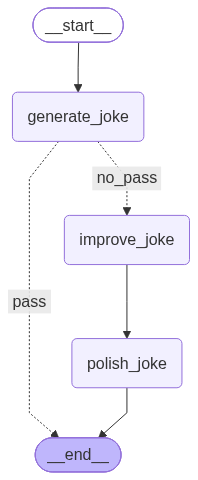

In [1]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END

from langchain.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek

from common import init_simple_dashscope_model

model = init_simple_dashscope_model(
    extra_body={
        "enable_thinking": False
    }
)

# 图状态
class OverAllState(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str

# 节点
def generate_joke(state: OverAllState) -> OverAllState:
    """第一次调用大模型，生成初始笑话"""

    msg = model.invoke(
        [HumanMessage(content=f"写一个关于“{state['topic']}”的简短笑话")]
    )
    return {"joke": msg.content}

def check_punchline(state: OverAllState) -> Literal["pass", "no_pass"]:
    """判断笑话中是否包含包袱"""

    # 简单判断：笑话中是否包含问号或感叹号
    if "?" in state["joke"] or "!" in state["joke"]:
        return "pass"
    return "no_pass"

def improve_joke(state: OverAllState) -> OverAllState:
    """第二次调用大模型，通过添加双关语改进笑话"""

    msg = model.invoke(
        [HumanMessage(content=f"通过添加双关语，让下面这个笑话变得更有趣：\n{state['joke']}")]
    )
    return {"improved_joke": msg.content}

def polish_joke(state: OverAllState) -> OverAllState:
    """第三次调用大模型，对笑话进行最终润色"""

    msg = model.invoke(
        [HumanMessage(content=f"为下面这个笑话添加一个出人意料的反转：\n{state['improved_joke']}")]
    )
    return {"final_joke": msg.content}

# 构建工作流
builder = StateGraph(state_schema=OverAllState)

# 添加节点
builder.add_node("generate_joke", generate_joke)
builder.add_node("improve_joke", improve_joke)
builder.add_node("polish_joke", polish_joke)

# 添加边，连接各个节点
builder.add_edge(START, "generate_joke")
builder.add_conditional_edges(
    "generate_joke",
    check_punchline,
    {
        "no_pass": "improve_joke",
        "pass": END,
    },
)
builder.add_edge("improve_joke", "polish_joke")
builder.add_edge("polish_joke", END)

# 编译工作流
graph = builder.compile()

# 调用工作流
response = graph.invoke({"topic": "猫"})
print(response)

# 绘制拓扑结构
from IPython.display import display
display(graph)

## Pallelization并行

{'topic': '猫', 'joke': '主人问猫：“你为什么总是把桌上的东西推下去？”\n\n猫淡定地舔了舔爪子说：“我在测试重力是否还在正常工作。毕竟，这是铲屎官唯一能稳定提供的服务。”', 'story': '午后的阳光透过百叶窗的缝隙，在老旧的木地板上投下斑驳的光影。橘猫“阿福”正趴在窗台上，尾巴有一搭没一搭地扫着尘埃。它已经在这里守了整整三个小时，眼睛半眯着，看似在打盹，实则耳朵微微颤动，捕捉着窗外每一丝风吹草动。\n\n突然，一只蓝色的蝴蝶轻盈地掠过玻璃。阿福的瞳孔瞬间放大，原本慵懒的身体像弹簧一样紧绷起来。它压低身子，胡须向前探出，喉咙里发出低沉的“呼噜”声。就在它准备扑向那抹蓝色的瞬间，蝴蝶却优雅地转身，飞向了更高处的树梢。\n\n阿福愣了一秒，随即若无其事地站起身，伸了一个长长的懒腰，仿佛刚才那个蓄势待发的猎手从未存在过。它抖了抖毛，跳下窗台，走到主人的脚边，用脑袋蹭了蹭对方的裤腿，发出一声娇软的“喵”。\n\n主人笑着放下手中的书，伸手挠了挠它的下巴。阿福眯起眼睛，享受着这份温暖，心里想着：捉蝴蝶太累了，还是做个被宠爱的家猫比较舒服。', 'poem': '**《午后的捕梦者》**\n\n阳光在窗台折叠成金毯，\n你蜷缩成一团柔软的云。\n胡须轻颤，捕捉风的低语，\n瞳孔里藏着深邃的黄昏。\n\n忽然跃起，如一道闪电，\n追逐那看不见的尘埃精灵。\n转瞬又归于静谧，\n只留尾巴尖，轻轻画着圆。', 'combined_output': '下面是一个关于“猫”的故事、笑话和诗歌！\n\n故事：\n午后的阳光透过百叶窗的缝隙，在老旧的木地板上投下斑驳的光影。橘猫“阿福”正趴在窗台上，尾巴有一搭没一搭地扫着尘埃。它已经在这里守了整整三个小时，眼睛半眯着，看似在打盹，实则耳朵微微颤动，捕捉着窗外每一丝风吹草动。\n\n突然，一只蓝色的蝴蝶轻盈地掠过玻璃。阿福的瞳孔瞬间放大，原本慵懒的身体像弹簧一样紧绷起来。它压低身子，胡须向前探出，喉咙里发出低沉的“呼噜”声。就在它准备扑向那抹蓝色的瞬间，蝴蝶却优雅地转身，飞向了更高处的树梢。\n\n阿福愣了一秒，随即若无其事地站起身，伸了一个长长的懒腰，仿佛刚才那个蓄势待发的猎手从未存在过。它抖了抖毛，跳下窗台，走到主人的脚边，用脑袋蹭了蹭对方的裤腿，发出一声娇软的“喵”。\n\n主人笑着放下手中的书，伸手挠了挠

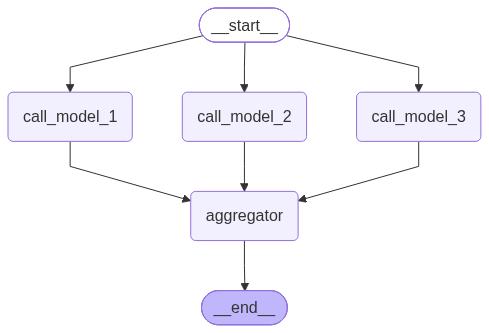

In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

from langchain.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek


from common import init_simple_dashscope_model

model = init_simple_dashscope_model(
    extra_body={
        "enable_thinking": False
    }
)

# 图状态
class OverAllState(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str

# 节点
def call_model_1(state: OverAllState) -> OverAllState:
    """第一次调用大模型，生成笑话"""

    msg = model.invoke(
        [HumanMessage(content=f"写一个关于“{state['topic']}”的简短的笑话")]
    )
    return {"joke": msg.content}

def call_model_2(state: OverAllState) -> OverAllState:
    """第二次调用大模型，生成故事"""

    msg = model.invoke(
        [HumanMessage(content=f"写一个关于“{state['topic']}”的简短的故事")]
    )
    return {"story": msg.content}

def call_model_3(state: OverAllState) -> OverAllState:
    """第三次调用大模型，生成诗歌"""

    msg = model.invoke(
        [HumanMessage(content=f"写一首关于“{state['topic']}”的简短的诗")]
    )
    return {"poem": msg.content}

def aggregator(state: OverAllState) -> OverAllState:
    """将笑话、故事和诗歌合并为单一输出"""

    combined = f"下面是一个关于“{state['topic']}”的故事、笑话和诗歌！\n\n"
    combined += f"故事：\n{state['story']}\n\n"
    combined += f"笑话：\n{state['joke']}\n\n"
    combined += f"诗歌：\n{state['poem']}"
    return {"combined_output": combined}

# 构建工作流
builder = StateGraph(state_schema=OverAllState)

# 添加节点
builder.add_node("call_model_1", call_model_1)
builder.add_node("call_model_2", call_model_2)
builder.add_node("call_model_3", call_model_3)
builder.add_node("aggregator", aggregator)

# 添加边，连接各个节点
builder.add_edge(START, "call_model_1")
builder.add_edge(START, "call_model_2")
builder.add_edge(START, "call_model_3")
builder.add_edge(["call_model_1", "call_model_2", "call_model_3"], "aggregator")
builder.add_edge("aggregator", END)

graph = builder.compile()

# 调用工作流
response = graph.invoke({"topic": "猫"})
print(response)

from IPython.display import display
display(graph)

## Routing

In [ ]:
from pydantic import BaseModel, Field
from typing import Literal,TypedDict
from langgraph.graph import StateGraph, START, END
from langchain.messages import HumanMessage, SystemMessage

from langchain_deepseek import ChatDeepSeek


from common import init_simple_dashscope_model

model = init_simple_dashscope_model(
    extra_body={
        "enable_thinking": False
    }
)

# 定义用于结构化输出的 Schema，作为路由判断依据
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(
        None,
        description="路由流程中的下一执行步骤",
    )

# 为大模型添加结构化输出能力
router = model.with_structured_output(Route)

# 图状态
class OverAllState(TypedDict):
    input: str
    decision: str
    output: str

# 节点
def model_call_1(state: OverAllState) -> OverAllState:
    """生成故事"""

    result = model.invoke(
        [HumanMessage(content=state["input"])]
    )
    return {"output": result.content}


def model_call_2(state: OverAllState) -> OverAllState:
    """生成笑话"""

    result = model.invoke(
        [HumanMessage(content=state["input"])]
    )
    return {"output": result.content}


def model_call_3(state: OverAllState) -> OverAllState:
    """生成诗歌"""

    result = model.invoke(
        [HumanMessage(content=state["input"])]
    )
    return {"output": result.content}


def model_call_router(state: OverAllState) -> OverAllState:
    """将用户输入路由到合适的节点"""

    # 调用具有结构化输出能力的大模型，完成路由判断
    decision = router.invoke(
        [
            SystemMessage(
                content=(
                    "根据用户的请求，将其路由到 story、joke 或 poem。"
                    "请求编写故事时返回 story，请求编写笑话时返回 joke，"
                    "请求编写诗歌时返回 poem。"
                )
            ),
            HumanMessage(content=state["input"]),
        ]
    )

    return {"decision": decision.step}


# 条件边函数：根据路由决策选择下一个节点
def route_decision(
        state: OverAllState
) -> Literal[
    "model_call_1",
    "model_call_2",
    "model_call_3",
    END
]:
    # 返回接下来要执行的节点名称
    if state["decision"] == "story":
        return "model_call_1"
    elif state["decision"] == "joke":
        return "model_call_2"
    elif state["decision"] == "poem":
        return "model_call_3"
    return END


# 构建工作流
builder = StateGraph(OverAllState)

# 添加节点
builder.add_node("model_call_1", model_call_1)
builder.add_node("model_call_2", model_call_2)
builder.add_node("model_call_3", model_call_3)
builder.add_node("model_call_router", model_call_router)

# 添加边，连接各个节点
builder.add_edge(START, "model_call_router")
builder.add_conditional_edges(
    "model_call_router",
    route_decision,
    {
        # route_decision 返回的名称：接下来要执行的节点名称
        "model_call_1": "model_call_1",
        "model_call_2": "model_call_2",
        "model_call_3": "model_call_3",
    },
)
builder.add_edge("model_call_1", END)
builder.add_edge("model_call_2", END)
builder.add_edge("model_call_3", END)

# 编译工作流
graph = builder.compile()

# 调用工作流
state = graph.invoke({"input": "写一个关于猫的笑话"})
print(state["output"])

# 显示工作流图
from IPython.display import display
display(graph)

## Orchestrator-worker

In [ ]:
from typing import Annotated, List, TypedDict
from collections.abc import Sequence

from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain_deepseek import ChatDeepSeek

from operator import add
from dotenv import load_dotenv
from pydantic import BaseModel, Field

from common import init_simple_dashscope_model

model = init_simple_dashscope_model(
    extra_body={
        "enable_thinking": False
    }
)

# 结构化输出的 Schema
class Section(BaseModel):
    name: str = Field(
        description="报告的章节名称",
    )
    description: str = Field(
        description="本节主题和核心思想的概述",
    )

class Sections(BaseModel):
    sections: List[Section] = Field(
        description="报告的章节列表",
    )

# 编排器
planner = model.with_structured_output(Sections)

# 图状态
class OverAllState(TypedDict):
    topic: str  # 报告主题
    sections: list[Section]  # 报告章节列表
    completed_sections: Annotated[
        list, add
    ]  # 所有工作节点并行写入该字段
    final_report: str  # 最终报告


# 工作节点状态
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, add]

# 节点
def orchestrator(state: OverAllState) -> OverAllState:
    """编排器：生成报告编写计划"""

    # 生成报告章节规划
    report_sections = planner.invoke(
        [
            SystemMessage(content="为这份报告生成一个章节规划。"),
            HumanMessage(content=f"报告主题如下：{state['topic']}"),
        ]
    )

    return {"sections": report_sections.sections}

def model_call(state: WorkerState) -> WorkerState:
    """工作节点：编写报告中的一个章节"""

    # 生成章节内容
    section = model.invoke(
        [
            SystemMessage(
                content=(
                    "根据提供的章节名称和章节描述编写报告内容。"
                    "不要在每个章节前添加额外的开场说明。"
                    "使用 Markdown 格式。"
                )
            ),
            HumanMessage(
                content=(
                    f"章节名称：{state['section'].name}\n"
                    f"章节描述：{state['section'].description}"
                )
            ),
        ]
    )

    # 将生成的章节写入已完成章节列表
    return {"completed_sections": [section.content]}


def synthesizer(state: OverAllState) -> OverAllState:
    """将所有章节合成为完整报告"""

    # 获取所有已完成的章节
    completed_sections = state["completed_sections"]

    # 将已完成章节拼接为最终报告
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}


# 条件边函数：为规划中的每个章节创建一个 model_call 工作节点
def assign_workers(state: OverAllState) -> Sequence[Send]:
    """为规划中的每个章节分配一个工作节点"""

    # 使用 Send API 并行启动各个章节的编写任务
    return [Send("model_call", {"section": s}) for s in state["sections"]]


# 构建工作流
builder = StateGraph(state_schema=OverAllState)

# 添加节点
builder.add_node("orchestrator", orchestrator)
builder.add_node("model_call", model_call)
builder.add_node("synthesizer", synthesizer)

# 添加边，连接各个节点
builder.add_edge(START, "orchestrator")
builder.add_conditional_edges(
    "orchestrator",
    assign_workers,
    ["model_call"],
)
builder.add_edge("model_call", "synthesizer")
builder.add_edge("synthesizer", END)

# 编译工作流
graph = builder.compile()

# 调用工作流
state = graph.invoke(
    {"topic": "撰写一份关于大语言模型缩放定律的报告"}
)

from IPython.display import Markdown, display

# 显示工作流图
display(graph)
# 渲染报告
Markdown(state["final_report"])

## Evaluator-optimizer

有一天，一只猫去面试。

面试官问它：“你有什么特长吗？”

猫自信地回答：“我会‘喵’语八级，精通捕鼠心理学，而且……”

面试官打断它：“停！我们招的是程序员，你会写代码吗？”

猫愣了一下，默默掏出一个键盘，在上面踩了一脚，然后指着屏幕上的一串乱码说：

“看，这是我刚写的 **Java**（爪哇）。” 🐱💻


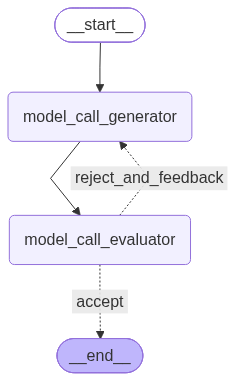

In [4]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langchain.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek

from dotenv import load_dotenv
from common import init_simple_dashscope_model

model = init_simple_dashscope_model(
    extra_body={
        "enable_thinking": False
    }
)
# 图状态
class OverAllState(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str

# 定义用于结构化输出的 Schema，作为笑话评估依据
class Feedback(BaseModel):
    grade: Literal["好笑", "不好笑"] = Field(
        description="判断这个笑话是否好笑。",
    )
    feedback: str = Field(
        description="如果笑话不好笑，请给出具体的改进建议。",
    )

# 为大模型添加结构化输出能力，定义评估器
evaluator = model.with_structured_output(Feedback)

# 节点
def model_call_generator(state: OverAllState) -> OverAllState:
    """大模型生成笑话"""

    if state.get("feedback"):
        msg = model.invoke(
            f"""
            写一个关于“{state['topic']}”的笑话。

            请参考下面的改进建议：
            {state['feedback']}
            """
        )
    else:
        msg = model.invoke(f"写一个关于“{state['topic']}”的笑话")

    return {"joke": msg.content}


def model_call_evaluator(state: OverAllState) -> OverAllState:
    """大模型评估笑话"""

    grade = evaluator.invoke(
        f"""
        请评估下面这个笑话是否好笑：

        {state['joke']}
        """
    )

    return {
        "funny_or_not": grade.grade,
        "feedback": grade.feedback,
    }


# 条件边函数：根据评估结果决定结束流程，或者返回笑话生成节点
def route_joke(state: OverAllState) -> Literal["accept", "reject_and_feedback", END]:
    """根据评估结果决定接受笑话或根据反馈重新生成"""

    if state["funny_or_not"] == "好笑":
        return "accept"
    elif state["funny_or_not"] == "不好笑":
        return "reject_and_feedback"
    return END

# 构建工作流
builder = StateGraph(state_schema=OverAllState)

# 添加节点
builder.add_node("model_call_generator", model_call_generator)
builder.add_node("model_call_evaluator", model_call_evaluator)

# 添加边，连接各个节点
builder.add_edge(START, "model_call_generator")
builder.add_edge("model_call_generator", "model_call_evaluator")
builder.add_conditional_edges(
    "model_call_evaluator",
    route_joke,
    {
        # route_joke 返回的名称：接下来要执行的节点
        "accept": END,
        "reject_and_feedback": "model_call_generator",
    },
)

# 编译工作流
graph = builder.compile()

# 调用工作流
state = graph.invoke({"topic": "猫"})
print(state["joke"])

# 显示工作流图
from IPython.display import display
display(graph)

## Agent

================================ Human Message =================================

今天北京天气怎么样？
================================== Ai Message ==================================

我来为您查询北京今天的天气情况。
Tool Calls:
  get_weather (call_cc7bdf1402764bc983dc6465)
 Call ID: call_cc7bdf1402764bc983dc6465
  Args:
    city: 北京
================================= Tool Message =================================
Name: get_weather

北京 今天天气不错
================================== Ai Message ==================================

北京今天天气不错！


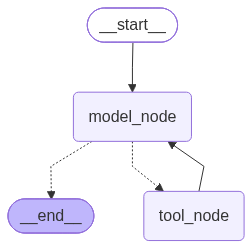

In [5]:
from typing import Literal
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt.tool_node import ToolNode

from langchain.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
from langchain.tools import tool

from common import init_simple_dashscope_model

model = init_simple_dashscope_model(
    extra_body={
        "enable_thinking": False
    }
)

@tool(parse_docstring=True)
def get_weather(city: str) -> str:
    """
    根据城市查询当日天气

    Args:
        city: 城市名称
    """
    return f"{city} 今天天气不错"

tools = [get_weather]
model_with_tools = model.bind_tools(tools=tools)

def model_node(state: MessagesState) -> MessagesState:
    messages = state["messages"]
    response = model_with_tools.invoke(input=messages)

    return {
        "messages": [response]
    }

def router(state: MessagesState) -> Literal["tool_node", END]:
    last_msg = state["messages"][-1]

    if last_msg.tool_calls:
        return "tool_node"
    return END

builder = StateGraph(state_schema=MessagesState)
builder.add_node("model_node", model_node)
builder.add_node("tool_node", ToolNode(tools=tools))

builder.add_edge(START, "model_node")
builder.add_conditional_edges("model_node", router, path_map=["tool_node", END])
builder.add_edge("tool_node", "model_node")

graph = builder.compile()

response = graph.invoke({"messages": [HumanMessage(content="今天北京天气怎么样？")]})
for msg in response["messages"]:
    msg.pretty_print()

from IPython.display import display
display(graph)